In [3]:
# Import libraries
import pandas as p
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
from mask2bbox import BBoxes
from skimage.io import imread

In [5]:
# Read data

segmentation = "stardist"
folder = "week3"
file = "s01c1"

target_df = pd.read_csv(f"/Users/miguelibarra/PycharmProjects/micronuclei_labeling_tool/out/week3_{file}_rf06_stardist.csv")
prediction_df = pd.read_csv(f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/{folder}/predictions/{segmentation}/{file}_predictions.csv")
# prediction_df = pd.read_csv(f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/{folder}/prediction/{file}_predictions.csv")

size = (256, 256)

boxes = BBoxes.from_mask(f"../data/Lindsay/{folder}/segmentation/{segmentation}/{file}.tif")
boxes.image = f"../data/Lindsay/{folder}/ometif/{file}.ome.tif"

rf = boxes.calculate_resizing_factor(0.6, size)
boxes = boxes.expand(25)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/24h_combined_071023-01-Stitching-03/predictions/stardist/24h_combined_071023-01-Stitching-03_s01.tif_predictions.csv'

In [111]:
print(target_df.shape)
print(prediction_df.shape)

(1837, 3)
(1837, 3)


In [112]:
target_df

,image,count,label
0,1,0,0
1,2,1,1
2,3,3,1
3,4,0,0
4,5,0,0
...,...,...,...
1832,1833,0,0
1833,1834,0,0
1834,1835,0,0
1835,1836,0,0


In [113]:
prediction_df

,image,score,micronuclei
0,1,-0.008532,0
1,2,0.887466,1
2,3,3.198295,3
3,4,0.037611,0
4,5,0.020144,0
...,...,...,...
1832,1833,-0.007540,0
1833,1834,0.005160,0
1834,1835,-0.059540,0
1835,1836,0.219224,0


In [114]:
def count_micronuclei(score):
    if score < 0:
        return int(0)
    elif score >= 0.75:
        return int(np.round(score, 0))
    else:
        return int(np.floor(score))

prediction_df["micronuclei_2"]=prediction_df.score.apply(lambda x: count_micronuclei(x))

In [115]:
# prediction_df["image"] = prediction_df["image"].apply(lambda x:int(x.split("_")[-1].split(".")[0]))
# prediction_df

In [116]:
# Merge target_df counts and prediction_df micronuclei into a new dataframe
data = pd.merge(target_df, prediction_df, on="image")
data

,image,count,label,score,micronuclei,micronuclei_2
0,1,0,0,-0.008532,0,0
1,2,1,1,0.887466,1,1
2,3,3,1,3.198295,3,3
3,4,0,0,0.037611,0,0
4,5,0,0,0.020144,0,0
...,...,...,...,...,...,...
1832,1833,0,0,-0.007540,0,0
1833,1834,0,0,0.005160,0,0
1834,1835,0,0,-0.059540,0,0
1835,1836,0,0,0.219224,0,0


In [117]:
# Get target counts
target_counts = data["count"].value_counts().sort_index().rename("target")

# Get prediction counts
prediction_counts = data["micronuclei"].value_counts().sort_index().rename("prediction")

# Merge target and prediction counts
counts = pd.merge(target_counts, prediction_counts, left_index=True, right_index=True, how="outer").fillna(0).astype(int)

# Convert index into a column named micronuclei
counts = counts.reset_index().rename(columns={"index": "micronuclei"})
counts

,micronuclei,target,prediction
0,0,1505,1542
1,1,287,273
2,2,36,19
3,3,8,3
4,4,1,0


/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


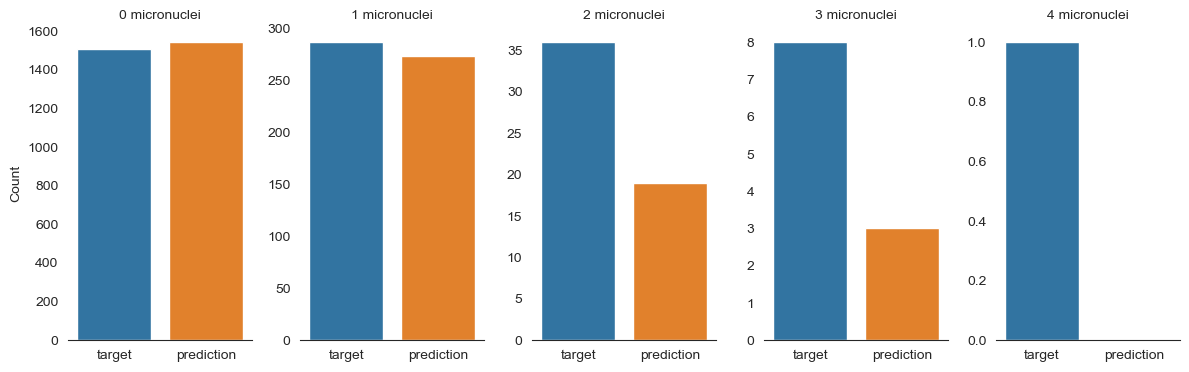

In [118]:
# Plot target and prediction counts
counts2plot = counts.melt(id_vars=["micronuclei"], var_name="kind", value_name="counts")
g = sns.catplot(data=counts2plot, x="kind", y="counts", col="micronuclei", kind="bar", height=4, aspect=.6, sharey=False)
g.set_axis_labels("", "Count")
g.set_titles("{col_name} {col_var}")
g.despine(left=True)

In [119]:
# Get total number of cells for target and prediction data
target_cells = counts["target"].sum()
prediction_cells = counts["prediction"].sum()

# Get total number of cells with micronuclei in target data and in prediction data
target_cin = counts["target"][1:].sum()
prediction_cin = counts["prediction"][1:].sum()

# Get total number of micronuclei in target data and in prediction data
target_mn = (counts["target"] * counts["target"].index).sum()
prediction_mn = (counts["prediction"] * counts["prediction"].index).sum()

# Get ratio  of cells with micronuclei in target data
target_cin_ratio = counts["target"][1:].sum() / counts["target"].sum()
prediction_cin_ratio = counts["prediction"][1:].sum() / counts["prediction"].sum()

# Get ratio of micronuclei in target data
target_mn_ratio = (counts["target"] * counts["target"].index).sum() / counts["target"].sum()
prediction_mn_ratio = (counts["prediction"] * counts["prediction"].index).sum() / counts["prediction"].sum()

# Convert the above to a dataframe with to columns one for target and one for prediction
summary = pd.DataFrame({"target": [target_cells, target_cin, target_mn, target_cin_ratio, target_mn_ratio],
                        "prediction": [prediction_cells, prediction_cin, prediction_mn, prediction_cin_ratio, prediction_mn_ratio]},
                        index=["cells", "cells with micronuclei", "micronuclei", "cells with micronuclei ratio", "micronuclei ratio"])
summary = summary.reset_index()
summary

,index,target,prediction
0,cells,1837.000000,1837.000000
1,cells with micronuclei,332.000000,295.000000
2,micronuclei,387.000000,320.000000
3,cells with micronuclei ratio,0.180729,0.160588
4,micronuclei ratio,0.210670,0.174197


/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


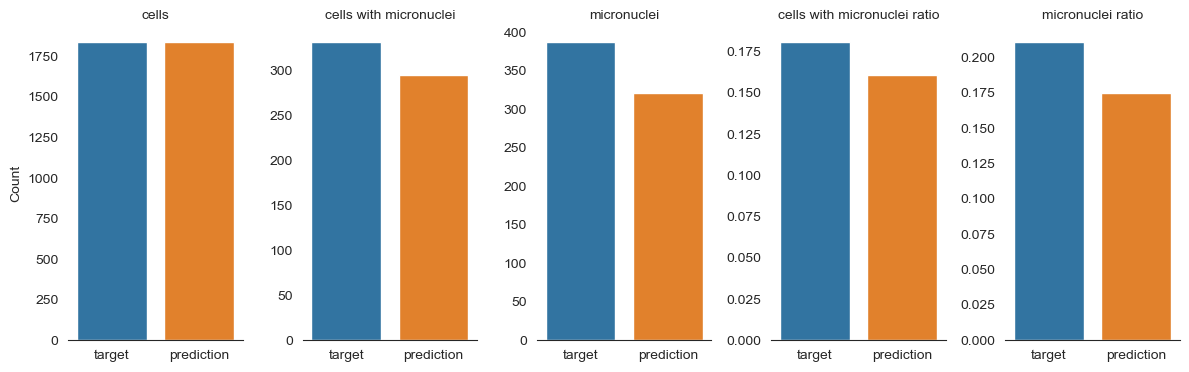

In [120]:
# Summary to plot
summary2plot = summary.melt(id_vars=["index"], var_name="kind", value_name="count")
g = sns.catplot(data=summary2plot, x="kind", y="count", col="index", kind="bar", height=4, aspect=.6, sharey=False)
g.set_axis_labels("", "Count")
g.set_titles("{col_name}")
g.despine(left=True)

 # Classification

In [121]:
# Calculate CIN from score, any score above 0.5 is considered to be CIN = 1
data["cin"] = (data["score"]>=0.5).astype(int)
data.head()

,image,count,label,score,micronuclei,micronuclei_2,cin
0,1,0,0,-0.008532,0,0,0
1,2,1,1,0.887466,1,1,1
2,3,3,1,3.198295,3,3,1
3,4,0,0,0.037611,0,0,0
4,5,0,0,0.020144,0,0,0


Text(72.72222222222221, 0.5, 'Target')

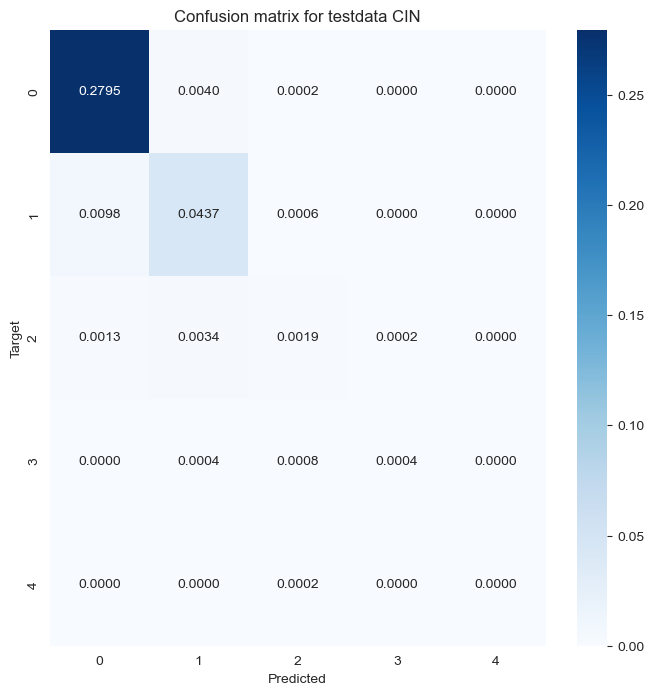

In [122]:
# Confusion matrix for CIN
cm = confusion_matrix(data["count"], data["micronuclei"])
# tp, fp, fn, tn = cm.ravel()
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.heatmap(cm/5306, annot=True, fmt=".4f", cmap="Blues", ax=ax,)
# ax.set_title(f"Confusion matrix for testdata CIN {tp+tn}/{tp+fp+fn+tn} = {(tp+tn)/(tp+fp+fn+tn):.2f}")
ax.set_title(f"Confusion matrix for testdata CIN")
ax.set_xlabel("Predicted")
ax.set_ylabel("Target")
# fig.savefig("../data/test_data/figures_cm.png", dpi=300)

In [123]:
print(classification_report(data["count"], data["micronuclei"]))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1505
           1       0.85      0.81      0.83       287
           2       0.53      0.28      0.36        36
           3       0.67      0.25      0.36         8
           4       0.00      0.00      0.00         1

    accuracy                           0.94      1837
   macro avg       0.60      0.46      0.51      1837
weighted avg       0.93      0.94      0.94      1837



/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [124]:
# Get F1 score
cm = confusion_matrix(data["label"], data["cin"])
tp, fp, fn, tn = cm.ravel()
print(classification_report(data["label"], data["cin"]))

# Get the false discovery rate
fdr = fp / (fp + tp)
fpr = fp / (fp + tn)

print(f"False discovery rate: {fdr:.4f}")
print(f"False positive rate:  {fpr:.4f}")

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1505
           1       0.93      0.82      0.87       332

    accuracy                           0.96      1837
   macro avg       0.94      0.90      0.92      1837
weighted avg       0.96      0.96      0.95      1837

False discovery rate: 0.0146
False positive rate:  0.0746


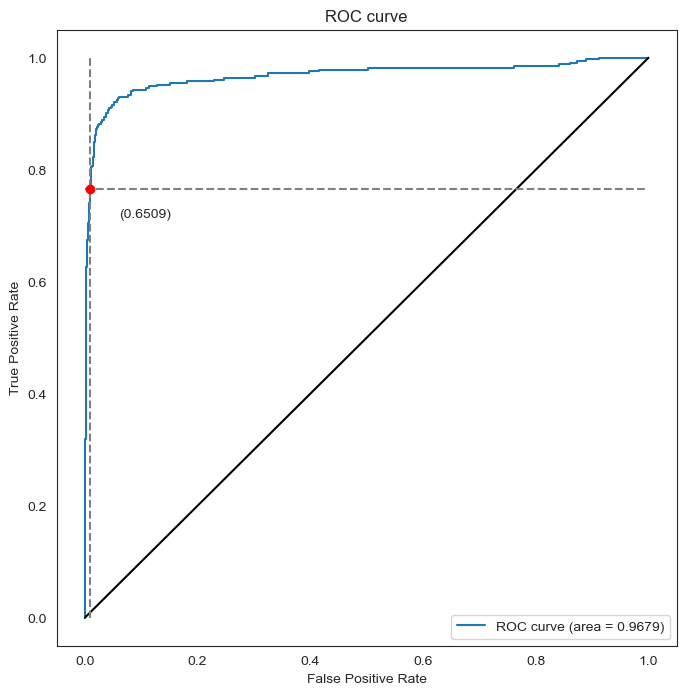

In [125]:
# Plot ROC curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

rocauc = roc_auc_score(data["label"], data["score"])
sns.set_style("white")
fpr, tpr, thresholds = roc_curve(data["label"], data["score"])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot(fpr, tpr, label=f"ROC curve (area = {rocauc:.4f})")
ax.plot([0, 1], [0, 1], 'k-')
cutoff = 26
ax.hlines(tpr[cutoff], 0, 1, linestyles="--", colors="grey")
ax.vlines(fpr[cutoff], 0, 1, linestyles="--", colors="grey")
ax.plot(fpr[cutoff], tpr[cutoff], "ro")
ax.text(fpr[cutoff]+0.05, tpr[cutoff]-0.05, f"({thresholds[cutoff]:.4f})")

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve')
ax.legend(loc="lower right")
# fig.savefig("../data/test_data/figures_roc.png", dpi=300)


# Regression

In [126]:
# Get mean squared error and mean absolute error
print(f"Mean squared error:      {mean_squared_error(data['count'], data['micronuclei'])}")
print(f"Mean absolute error:     {mean_absolute_error(data['count'], data['micronuclei'])}")
print(f"Root mean squared error: {mean_squared_error(data['count'], data['micronuclei'], squared=False)}")

Mean squared error:      0.07784431137724551
Mean absolute error:     0.0658682634730539
Root mean squared error: 0.27900593430471243


Text(0, 0.5, 'Prediction')

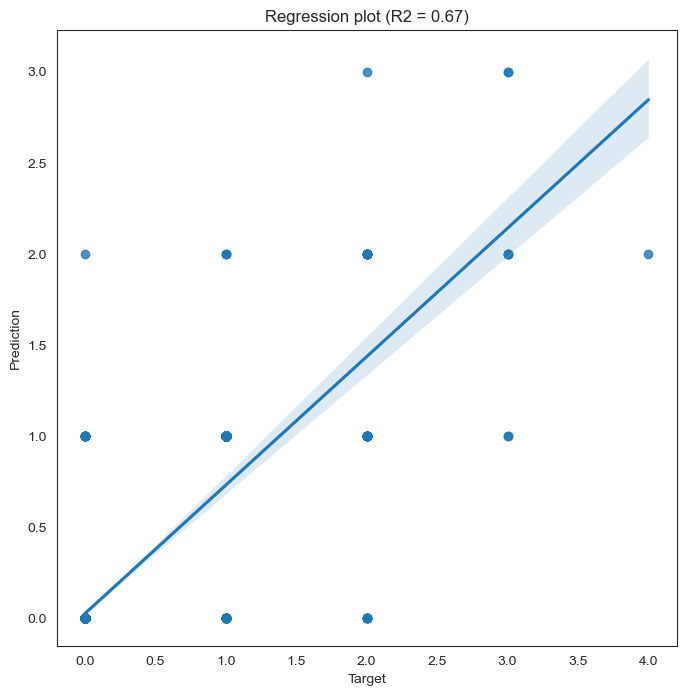

In [127]:
# Import r2 score
from sklearn.metrics import r2_score
# Plot regression plot
sns.set_style("white")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.regplot(data=data, x="count", y="micronuclei", ax=ax)
# get r2 score
r2 = r2_score(data["count"], data["micronuclei"])
ax.set_title(f"Regression plot (R2 = {r2:.2f})")
ax.set_xlabel("Target")
ax.set_ylabel("Prediction")
# fig.savefig("../data/test_data/figures_regression.png", dpi=300)

# Exloration of results

In [128]:
# Get the false positive images between label and cin
# data["micronuclei"] = data["micronuclei_2"]
fp_images = data[(data["count"]==0) & (data["micronuclei"]>=1)]
fn_images = data[(data["count"]>=1) & (data["micronuclei"]==0)]
tp_images = data[(data["count"]>=1) & (data["micronuclei"]>=1)]

In [129]:
print(f"False positves  = {fp_images.shape[0]}")
print(f"False negatives = {fn_images.shape[0]}")
print(f"True positves   = {tp_images.shape[0]}")

False positves  = 22
False negatives = 59
True positves   = 273


In [130]:
def plot_crop_grid(data, cols=8, cmap="turbo"):
    # Estimate the number of rows needed for the plot
    rows = len(data)//cols if len(data)%cols==0 else len(data)//cols+1

    # Plot
    sns.set_style("white")
    fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), )
    for i,(ix, j) in enumerate(data.iterrows()):
        cell_id = int(j.image)-1
        ax[ i//cols, i%cols].matshow(boxes.extract_single(cell_id, rf[cell_id], size), cmap=cmap)
        ax[ i//cols, i%cols].set_title(f"{int(j.image)} = T: {j['count']:.0f} - {j['micronuclei']:.0f} P\n{j['score']}")
        ax[ i//cols, i%cols].set_yticks([])
        ax[ i//cols, i%cols].set_xticks([])

    sns.despine(left=True, bottom=True)
    fig.tight_layout()

### False Positives

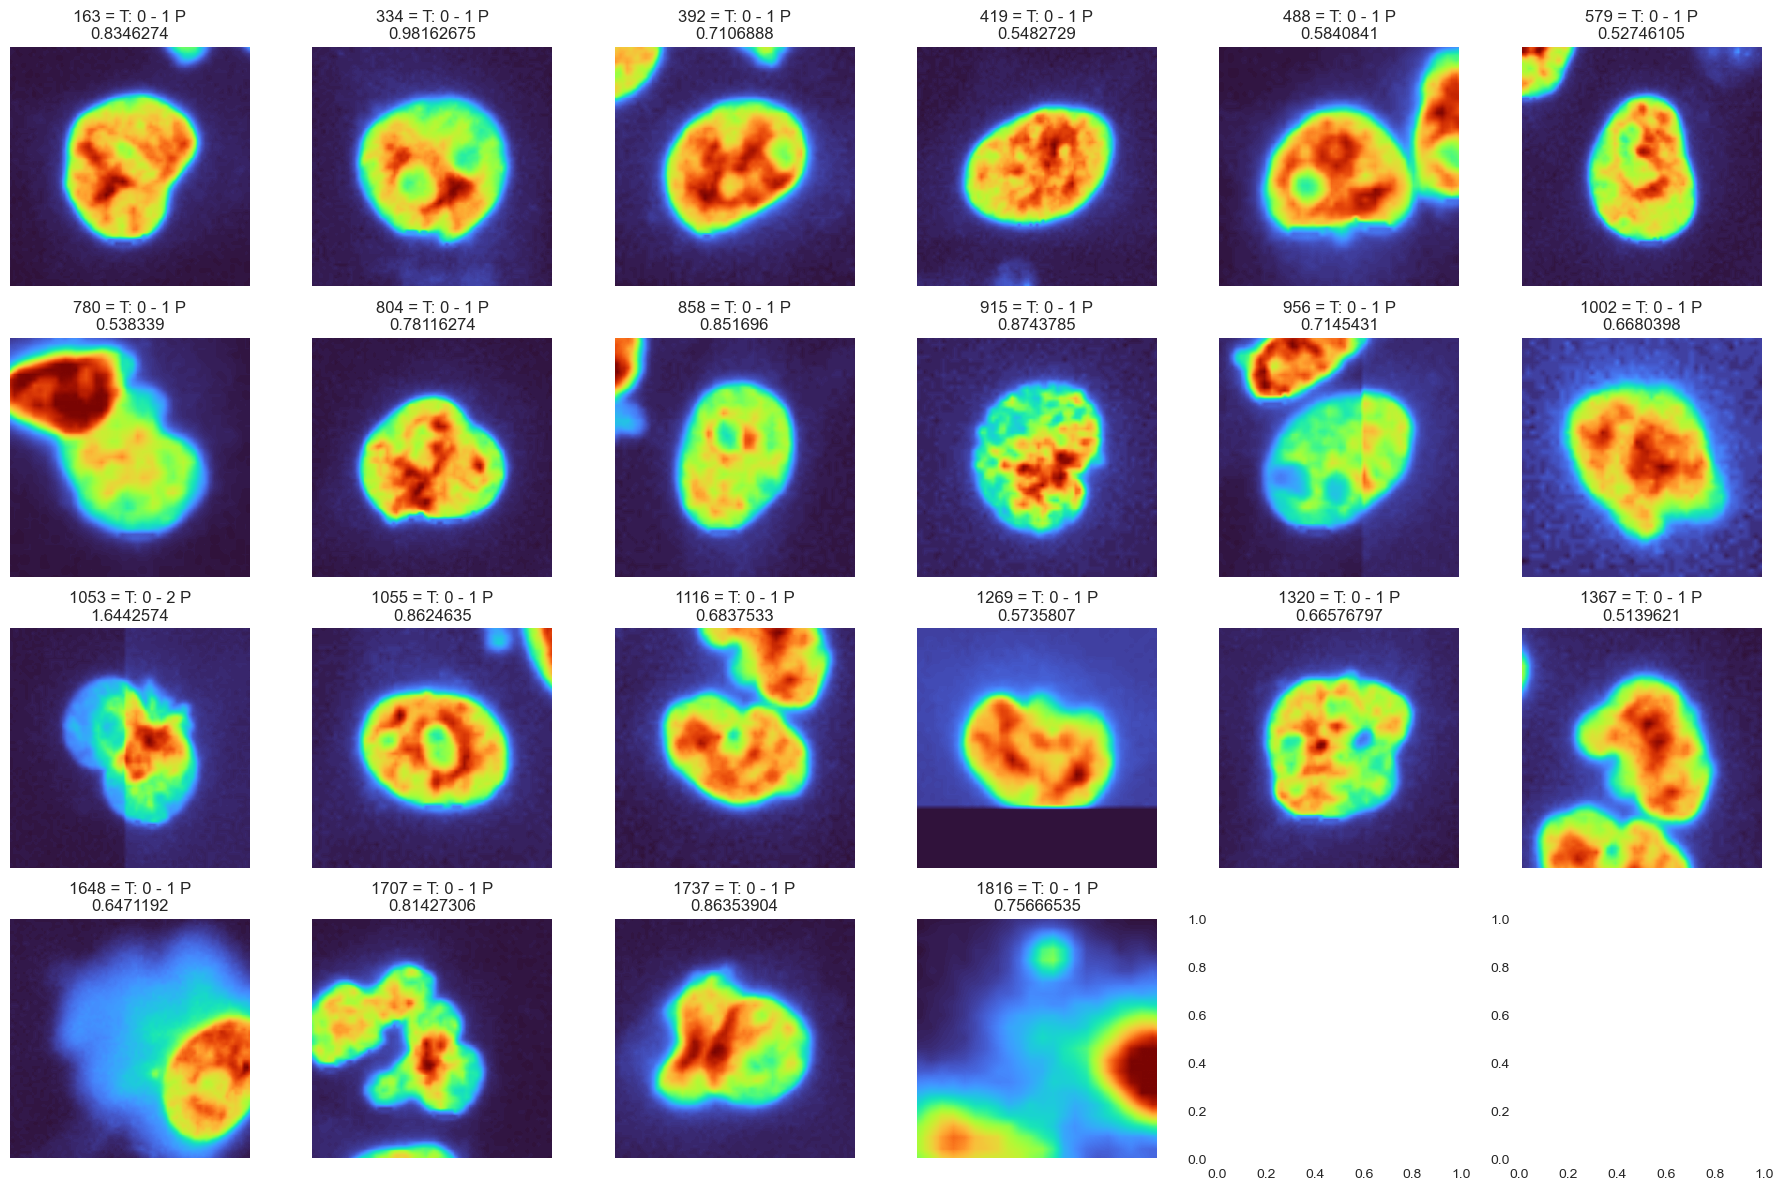

In [131]:
# Plot false positives sorting by score
plot_crop_grid(fp_images, cols=6, cmap="turbo")

### False Negatives

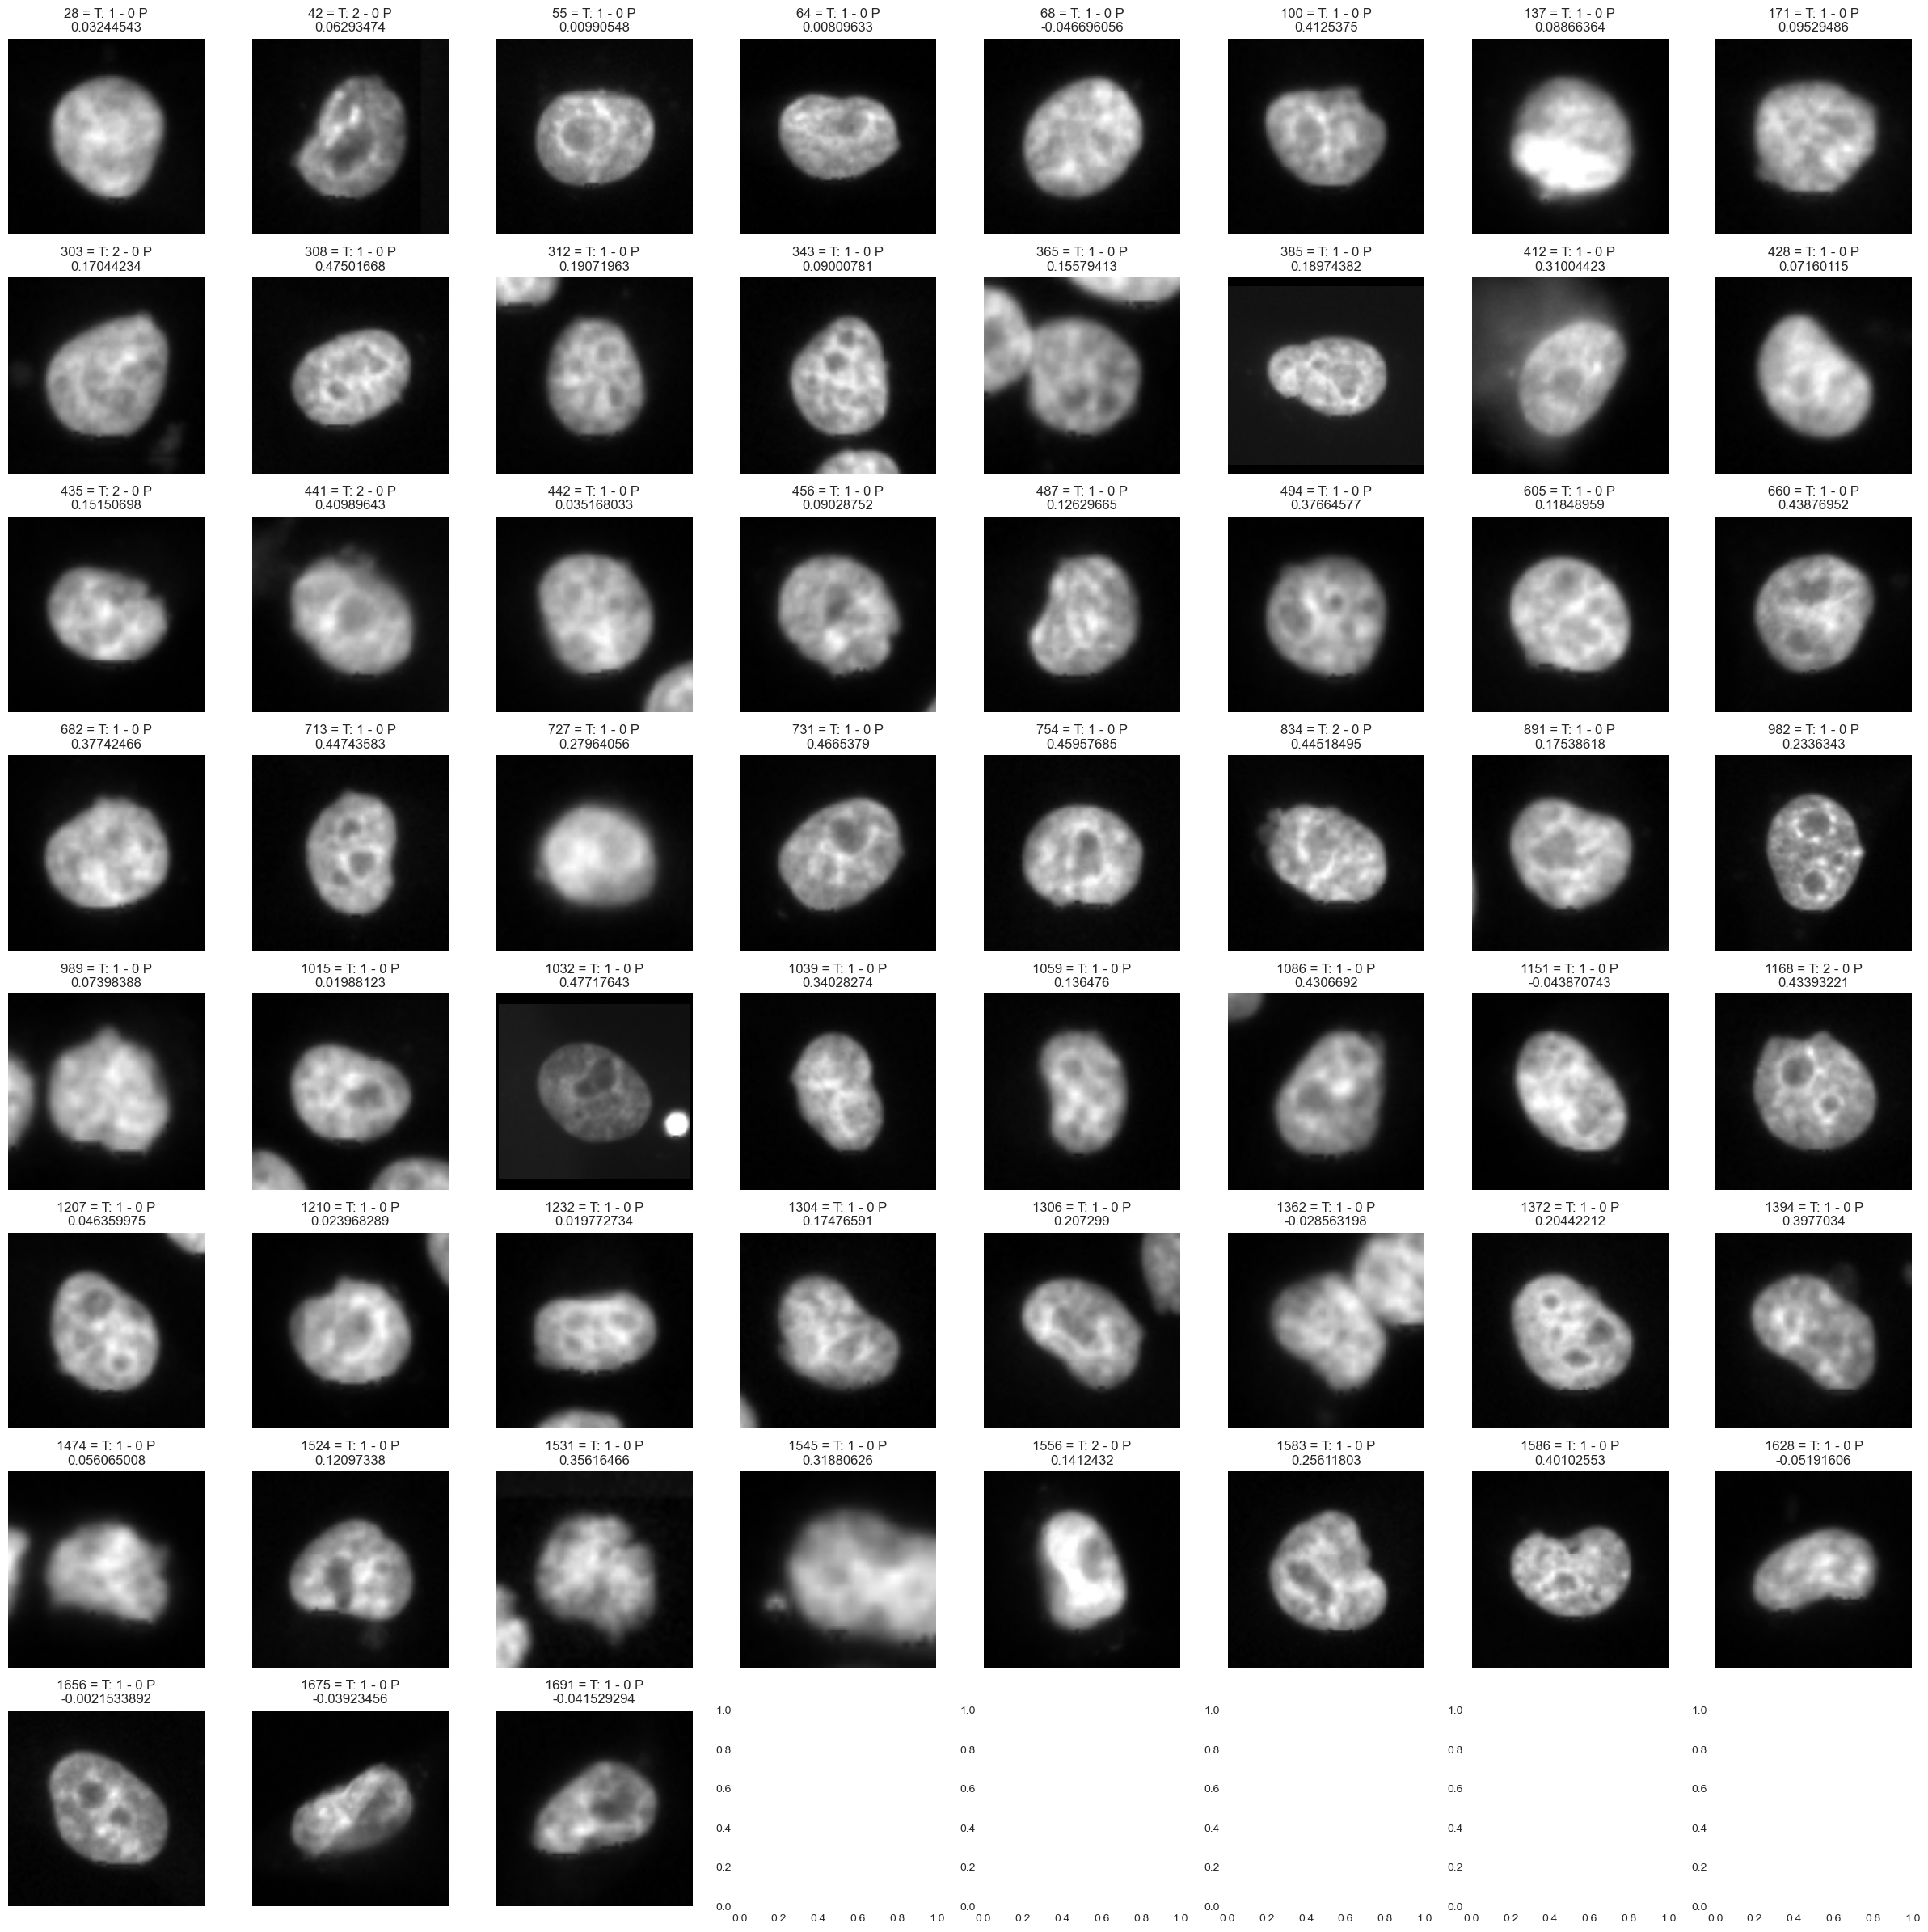

In [133]:
# Plot false negatives
plot_crop_grid(fn_images, cols=8, cmap="gray")